In [1]:
!pip install -q ultralytics fast-alpr onnxruntime opencv-python-headless

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 1.7 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO
from fast_alpr import ALPR
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import os
import torch
from pathlib import Path
from collections import defaultdict
from datetime import datetime, timedelta

print("CUDA available:", torch.cuda.is_available())

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
CUDA available: False


In [3]:
# uploading first model (car detection )
CAR_MODEL_PATH = "/content/best (2).pt"
car_model = YOLO(CAR_MODEL_PATH)
print("Car detection classes:", car_model.names)

alpr = ALPR(
    detector_model="yolo-v9-t-384-license-plate-end2end",
    ocr_model="cct-xs-v2-global-model",
)
print("Fast-ALPR is ready!")

Car detection classes: {0: 'car', 1: 'free'}


INFO:open_image_models.detection.core.yolo_v9.inference:Using ONNX Runtime with ['AzureExecutionProvider', 'CPUExecutionProvider'] provider(s)

Fast-ALPR is ready!


In [4]:
# reading plate from a phito with alpr
def detect_and_read_plate_alpr(image_path, alpr_model):
    image = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    alpr_results = alpr_model.predict(image)

    plates_info = []
    for r in alpr_results:
        bbox = r.detection.bounding_box
        x1, y1, x2, y2 = int(bbox.x1), int(bbox.y1), int(bbox.x2), int(bbox.y2)
        detection_conf = float(r.detection.confidence)

        plate_crop = image_rgb[y1:y2, x1:x2]
        plate_text = r.ocr.text if r.ocr else ""
        ocr_conf = float(np.mean(r.ocr.confidence)) if r.ocr and r.ocr.confidence else 0.0

        plates_info.append({
            "bbox": (x1, y1, x2, y2),
            "detection_conf": detection_conf,
            "plate_crop": plate_crop,
            "text": plate_text,
            "ocr_conf": ocr_conf
        })

    return image_rgb, plates_info

In [5]:
# importing test images in these 2 cells
!pip install -q roboflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 111.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.0 MB/s eta 0:00:00


In [ ]:
# from google.colab import userdata
# from roboflow import Roboflow

# ROBOFLOW_API_KEY = userdata.get("KERMIA_ROBOFLOW_API_KEY")
# print("API key loaded:", ROBOFLOW_API_KEY is not None)
# rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# project = rf.workspace("roboflow-universe-projects").project("license-plate-recognition-rxg4e")
# version = project.version(11)
# dataset = version.download("yolov8")

# TEST_IMAGES_DIR = Path(dataset.location) / "test" / "images"
# test_images = list(TEST_IMAGES_DIR.glob("*"))
# print(f"عدد صور الاختبار: {len(test_images)}")

In [6]:
from google.colab import userdata
from roboflow import Roboflow

ROBOFLOW_API_KEY = userdata.get("KERMIA_ROBOFLOW_API_KEY")
print("API key loaded:", ROBOFLOW_API_KEY is not None)

API key loaded: True


In [7]:
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

project = rf.workspace("roboflow-universe-projects").project(
    "license-plate-recognition-rxg4e"
)

version = project.version(11)

dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to License-Plate-Recognition-11 in yolov8:: 100%|██████████| 20262/20262 [00:04<00:00, 4092.91it/s]


In [8]:
#هناخد التيست داتا بس
TEST_IMAGES_DIR = Path("/content/License-Plate-Recognition-11/test/images")
test_images = list(TEST_IMAGES_DIR.glob("*"))
print(f"عدد صور الاختبار: {len(test_images)}")

عدد صور الاختبار: 1020


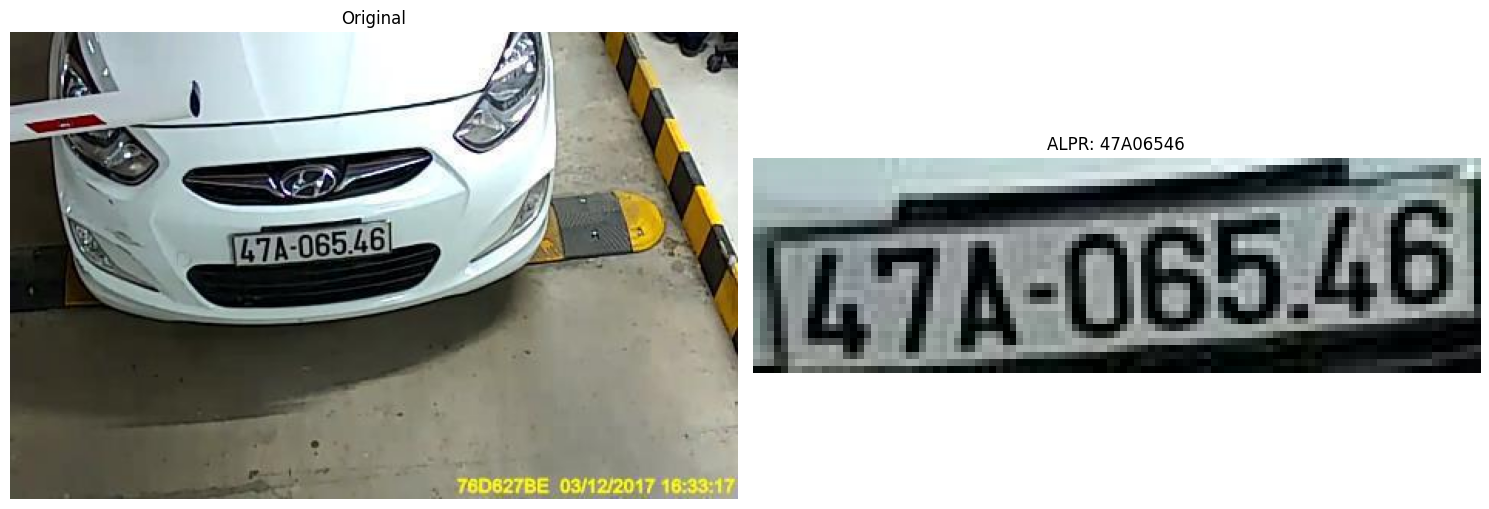

ALPR: 47A06546


In [9]:
sample_img_test = test_images[0]
image_rgb, plates_info = detect_and_read_plate_alpr(sample_img_test, alpr)

if plates_info:
    fig, axes = plt.subplots(1, len(plates_info) + 1, figsize=(15, 5))
    axes[0].imshow(image_rgb)
    axes[0].set_title("Original")
    axes[0].axis("off")
    for i, plate in enumerate(plates_info):
        axes[i + 1].imshow(plate["plate_crop"])
        axes[i + 1].set_title(f"ALPR: {plate['text']}")
        axes[i + 1].axis("off")
    plt.tight_layout()
    plt.show()
    print((f"ALPR: {plate['text']}"))
else:
    print("مفيش لوحة اتكشفت في الصورة دي")

In [10]:
batch_results_v2 = []

for img_path in test_images:
    _, plates_info = detect_and_read_plate_alpr(img_path, alpr)

    if not plates_info:
        batch_results_v2.append({
            "image": img_path.name, "plates_found": 0,
            "text": "-", "detection_conf": None, "ocr_conf": None
        })
    else:
        for plate in plates_info:
            batch_results_v2.append({
                "image": img_path.name,
                "plates_found": len(plates_info),
                "text": plate["text"],
                "detection_conf": round(plate["detection_conf"], 3),
                "ocr_conf": round(plate["ocr_conf"], 3)
            })

results_df_v2 = pd.DataFrame(batch_results_v2)

total_images = len(test_images)
images_with_detection = results_df_v2[results_df_v2["plates_found"] > 0]["image"].nunique()
images_with_text = results_df_v2[results_df_v2["text"].str.strip() != ""]["image"].nunique()

print(f"إجمالي الصور: {total_images}")
print(f"صور فيها لوحة اتكشفت: {images_with_detection} ({images_with_detection/total_images*100:.1f}%)")
print(f"صور فيها نص اتقرا: {images_with_text} ({images_with_text/total_images*100:.1f}%)")
print(f"متوسط ثقة الـ detection: {results_df_v2['detection_conf'].mean():.3f}")
print(f"متوسط ثقة الـ OCR: {results_df_v2['ocr_conf'].mean():.3f}")

results_df_v2

إجمالي الصور: 1020
صور فيها لوحة اتكشفت: 984 (96.5%)
صور فيها نص اتقرا: 1011 (99.1%)
متوسط ثقة الـ detection: 0.835
متوسط ثقة الـ OCR: 0.967


,image,plates_found,text,detection_conf,ocr_conf
0,CarLongPlate212_jpg.rf.f1856aee2196cf3863ccc30...,1,47A06546,0.900,1.000
1,CarLongPlateGen1618_jpg.rf.947acbbf8f8db4c6d4b...,1,51F16159,0.865,1.000
2,xemay2005_jpg.rf.49b077f8b14d7ae789cabc992463f...,1,59F147404,0.823,1.000
3,CarLongPlateGen3083_jpg.rf.f53acde17ee8a34edd0...,1,51G51332,0.882,1.000
4,CarLongPlateGen970_jpg.rf.a7662abba6d3611ab329...,1,51F59011,0.838,0.998
...,...,...,...,...,...
1051,CarLongPlateGen2690_jpg.rf.33c2e2c871c79ea6159...,1,51F22261,0.808,1.000
1052,CarLongPlateGen1367_jpg.rf.9b1ab317d851e83ba1c...,1,52P5688,0.836,0.933
1053,xemay1603_jpg.rf.460db10e6e86876c4fc550f2ac263...,1,79N118893,0.889,1.000
1054,WhatsApp-Image-2022-04-04-at-1-29-25-PM_jpeg_j...,1,NWJ9190,0.907,1.000


In [ ]:
# خليها كده دلوقتي علشان مش عارفين نتعامل مع الفيديو في تحديد نمره العربية

# if we wanted to process videos in the futuer
# def process_video(video_path, car_model, alpr_model,
#                    car_conf=0.4, vid_stride=1, fps_override=None,
#                    car_class_name="car"):
#     vehicle_plate_history = defaultdict(list)
#     vehicle_frame_range = {}

#     cap = cv2.VideoCapture(video_path)
#     fps = fps_override or cap.get(cv2.CAP_PROP_FPS) or 30
#     cap.release()

#     results_stream = car_model.track(
#         source=video_path, conf=car_conf, iou=0.4, imgsz=1280,
#         tracker="bytetrack.yaml", persist=True, stream=True,
#         vid_stride=vid_stride, verbose=False
#     )

#     car_names = car_model.names
#     frame_idx = 0

#     for frame_result in results_stream:
#         frame_bgr = frame_result.orig_img
#         boxes = frame_result.boxes

#         if boxes.id is not None:
#             for box, track_id in zip(boxes, boxes.id):
#                 cls_name = car_names[int(box.cls[0])]
#                 if cls_name != car_class_name:
#                     continue

#                 track_id = int(track_id)
#                 if track_id not in vehicle_frame_range:
#                     vehicle_frame_range[track_id] = {"first_frame": frame_idx, "last_frame": frame_idx}
#                 else:
#                     vehicle_frame_range[track_id]["last_frame"] = frame_idx

#                 x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
#                 car_crop = frame_bgr[y1:y2, x1:x2]
#                 if car_crop.size == 0:
#                     continue

#                 alpr_results = alpr_model.predict(car_crop)
#                 for r in alpr_results:
#                     plate_text = r.ocr.text if r.ocr else ""
#                     ocr_conf = float(np.mean(r.ocr.confidence)) if r.ocr and r.ocr.confidence else 0.0
#                     if plate_text and plate_text.strip():
#                         vehicle_plate_history[track_id].append((plate_text, ocr_conf))

#         frame_idx += 1

#     return vehicle_plate_history, vehicle_frame_range, fps

In [12]:
def process_video_track_only(video_path, car_model,
                               car_conf=0.4, vid_stride=1, fps_override=None,
                               car_class_name="car"):
    """
    نسخة اختبار سريعة: بتتبع العربيات بس من غير ما تشغل ALPR خالص
    """
    vehicle_frame_range = {}

    cap = cv2.VideoCapture(video_path)
    fps = fps_override or cap.get(cv2.CAP_PROP_FPS) or 30
    cap.release()

    results_stream = car_model.track(
        source=video_path, conf=car_conf, iou=0.4, imgsz=1280,
        tracker="bytetrack.yaml", persist=True, stream=True,
        vid_stride=vid_stride, verbose=False
    )

    car_names = car_model.names
    frame_idx = 0

    for frame_result in results_stream:
        boxes = frame_result.boxes

        if boxes.id is not None:
            for box, track_id in zip(boxes, boxes.id):
                cls_name = car_names[int(box.cls[0])]
                if cls_name != car_class_name:
                    continue

                track_id = int(track_id)
                if track_id not in vehicle_frame_range:
                    vehicle_frame_range[track_id] = {"first_frame": frame_idx, "last_frame": frame_idx}
                else:
                    vehicle_frame_range[track_id]["last_frame"] = frame_idx

        frame_idx += 1

    return vehicle_frame_range, fps


In [13]:
def finalize_vehicle_plates(vehicle_plate_history, confidence_threshold=0.4):
    final_results = {}
    for track_id, readings in vehicle_plate_history.items():
        if not readings:
            continue
        best_text, best_conf = max(readings, key=lambda r: r[1])
        status = "reliable" if best_conf >= confidence_threshold else "needs_review"
        final_results[track_id] = {
            "plate_text": best_text,
            "confidence": round(best_conf, 3),
            "status": status,
            "num_readings": len(readings)
        }
    return final_results

In [14]:
def build_deliverable_track_only(vehicle_frame_range, fps, video_start_time=None):
    if video_start_time is None:
        video_start_time = datetime.now()

    records = []
    for track_id, frame_range in vehicle_frame_range.items():
        first_frame = frame_range["first_frame"]
        last_frame = frame_range["last_frame"]

        entry_time = video_start_time + timedelta(seconds=first_frame / fps)
        exit_time = video_start_time + timedelta(seconds=last_frame / fps)

        records.append({
            "vehicle_id": track_id,
            "plate_number": 0,   # مؤقت للاختبار بس
            "entry_time": entry_time.isoformat(),
            "exit_time": exit_time.isoformat(),
            "confidence": 0,
            "status": "test_mode"
        })

    return records

In [15]:
print(CAR_MODEL_PATH)

/content/best (2).pt


In [16]:
VIDEO_PATH = "/content/parking_vid.mp4"

vehicle_frame_range, fps = process_video_track_only(
    VIDEO_PATH, car_model, car_conf=0.4, car_class_name="car", vid_stride=5
)

print(f"عدد العربيات المتتبعة: {len(vehicle_frame_range)}")

deliverable_records = build_deliverable_track_only(vehicle_frame_range, fps)

with open("/content/member2_deliverable_test.json", "w", encoding="utf-8") as f:
    json.dump(deliverable_records, f, ensure_ascii=False, indent=2)

print(f"✅ الملف جاهز: {len(deliverable_records)} سجل")
for r in deliverable_records:
    print(r)

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 373ms
Prepared 1 package in 96ms
Installed 1 package in 3ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 1.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

عدد العربيات المتتبعة: 159
✅ الملف جاهز: 159 سجل
{'vehicle_id': 1, 'plate_number': 0, 'entry_time': '2026-08-19T05:07:01.109737', 'exit_time': '2026-08-19T05:07:11.556261', 'confidence': 0, 'status': 'test_mode'}
{'vehicle_id': 2, 'plate_number': 0, 'entry_time': '2026-08-19T05:07:01.109737', 'exit_time': '2026-08-19T05:07:11.422760', 'confidence': 0, 'status': 'test_mode'}
{'vehicle_id': 3, 'plate_number': 0, 'entry_time': '2026-08-19T05:07:01.109737', 'exit_time': '2026-08-19T05:07:11.422760', 'confidence': 0, 'status': 'test_mode'}
{'vehicle_id': 4, 'plate_number': 0, 'entry_time': '2026-08-19T05:07:01.109737', 'exit_time': '2026-08